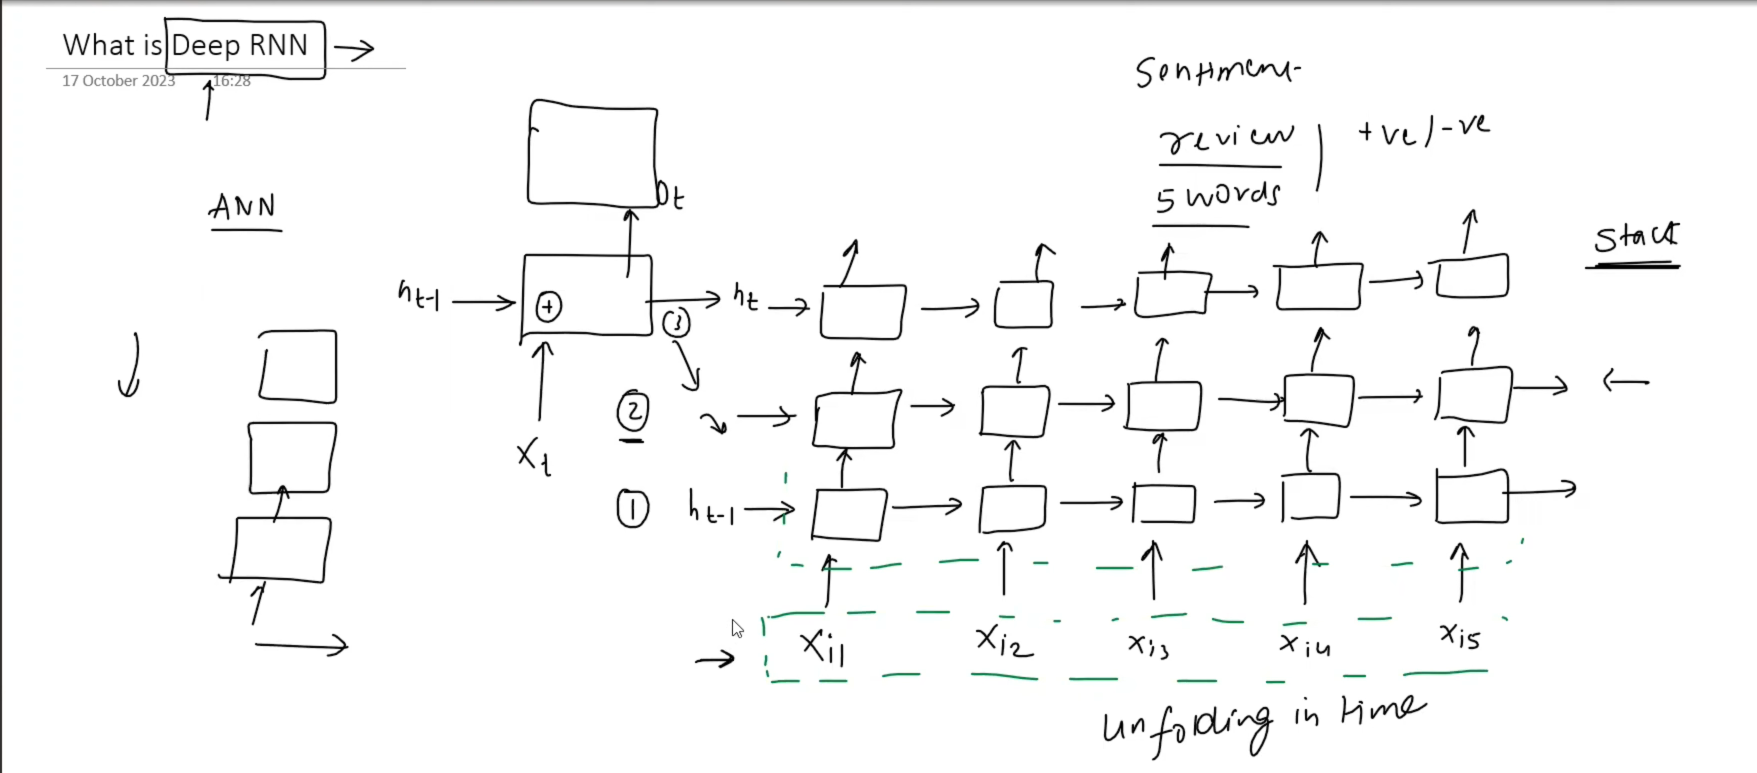

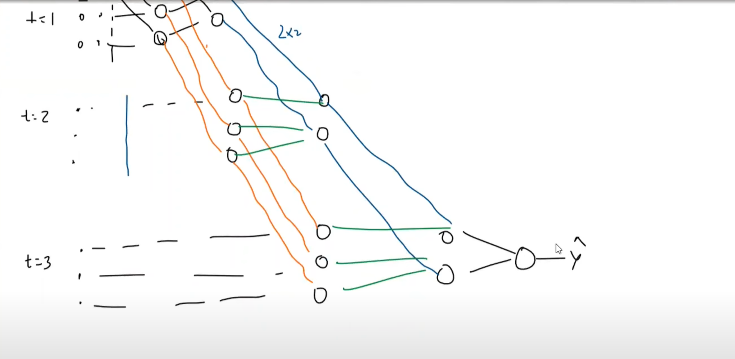

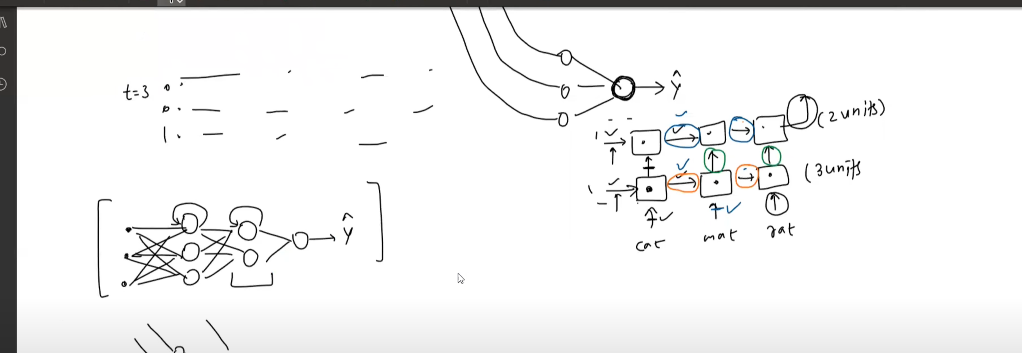

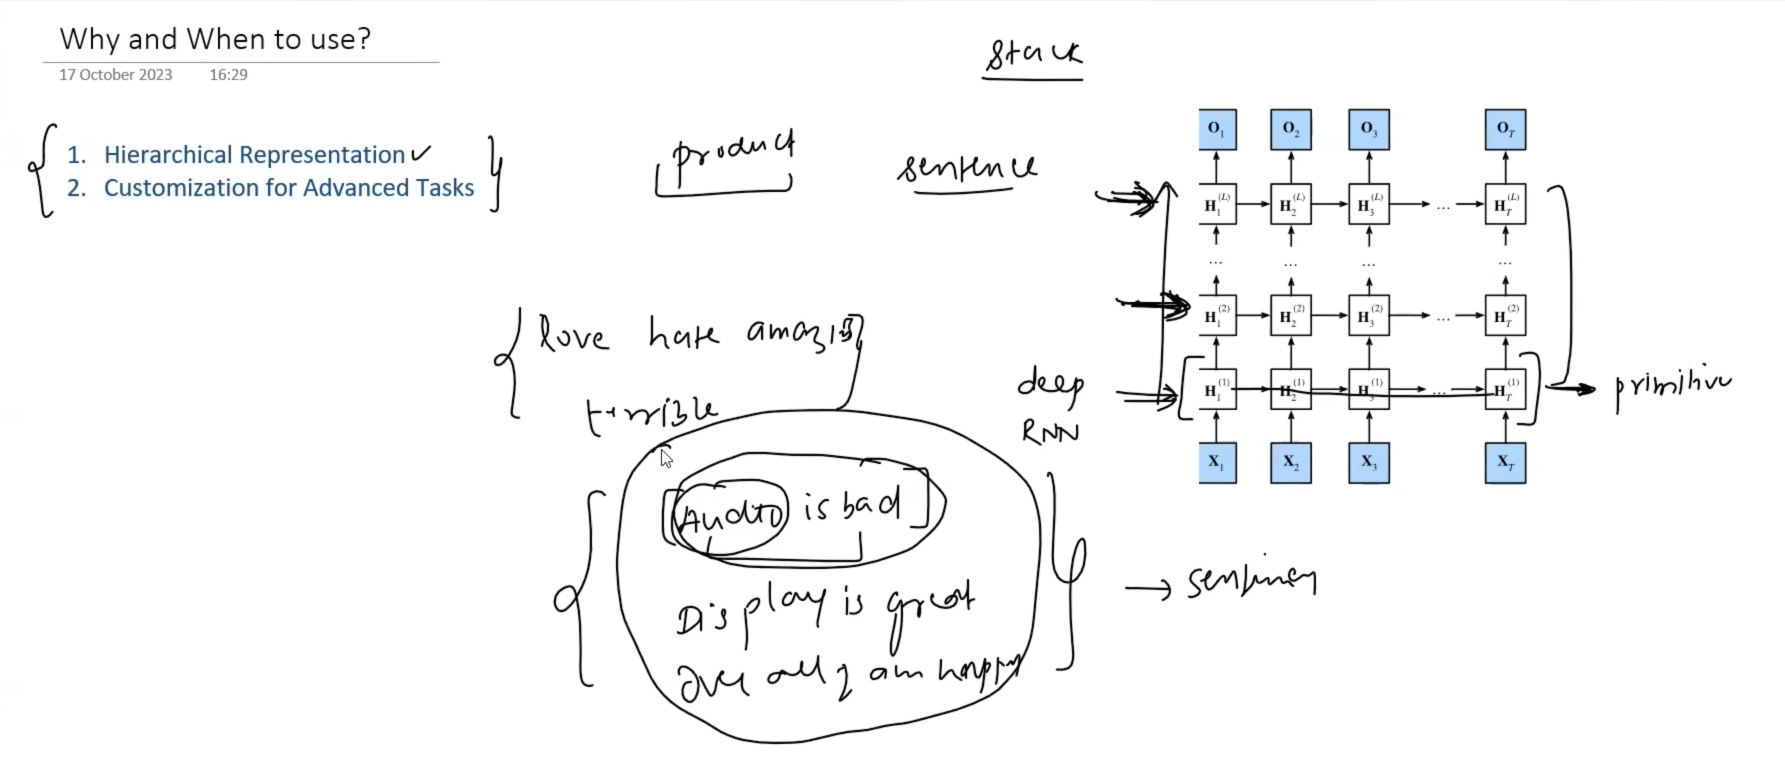



---

# 🧱 1. What is a Deep RNN?

### 🔹 First: Simple RNN (Recurrence)

A **simple RNN** reads input one step at a time:
- Input $ x_t $
- Hidden state $ h_t $ = memory
- Output $ o_t $

It "unfolds" over time:

```
x₁ → [RNN] → h₁ → o₁
     ↓        ↓
x₂ → [RNN] → h₂ → o₂
     ↓        ↓
x₃ → [RNN] → h₃ → o₃
```

👉 This is called **"unfolding in time"** (your image shows this clearly).

But it has a problem:  
❌ **Vanishing Gradient Problem** – it forgets long-term patterns.

---

### 🔹 So: What is a Deep RNN?

A **Deep RNN** adds **multiple layers** stacked on top of each other.

Like a deep neural network, but for sequences.

#### ✅ Structure:
- Bottom layer: processes raw input
- Middle layers: learn complex patterns
- Top layer: makes final decision

Your image shows:
```
[Input] → Layer 1 → Layer 2 → Layer 3 → [Output]
```
Each layer passes its hidden state forward in time AND up to the next layer.

> Think of it like reading a book:
> - Layer 1: Understands words
> - Layer 2: Understands phrases
> - Layer 3: Understands emotions or meaning

This is called **hierarchical representation**.

---

### 🔹 Example: Sentiment Analysis

Task: Classify a review as positive or negative.

Review: *"I love this product, but the delivery was terrible."*

- Words: `love`, `product`, `terrible`, etc.
- But meaning depends on context!

With **Deep RNN**:
- Lower layer: sees individual words
- Upper layer: combines ideas like “love” + “but” + “terrible” → mixed sentiment

Your diagram shows:
```
x_i1 → x_i2 → x_i3 → x_i4 → x_i5
   ↑       ↑       ↑       ↑       ↑
   └───┬────┴────┬────┴────┬────┴────┘
       ▼         ▼         ▼
     [Layer 1]  [Layer 2]  [Layer 3]
              →→→→→→→→→→→→→→→→→→→→→→→→→→→
                          ▼
                         Output: Positive / Negative
```

✅ Deep RNN can capture **complex meanings** across time and depth.

---

## 🌟 2. Why Use Deep RNN?

### ✅ Two Main Reasons:

| Reason | Explanation |
|-------|-------------|
| **1. Hierarchical Representation** | Like human thinking: first understand words, then phrases, then full meaning |
| **2. Customization for Advanced Tasks** | You can design layers for specific jobs (e.g., one for grammar, one for emotion) |

Your image shows:  
> “*I love this product, but the play is great. Overall I am happy.*”  
> Even if part says “bad”, overall is positive → Deep RNN learns that!

---

## 🚀 3. From Deep RNN to LSTM & GRU

Simple RNNs forget long-term info.  
So we need better memory systems.

### 🔹 LSTM (Long Short-Term Memory)

#### 📌 Idea: Add a **memory cell** and **gates**

LSTM has **four gates**:
- **Forget gate**: decides what to forget
- **Input gate**: decides what to store
- **Output gate**: decides what to output
- **Memory cell**: stores long-term info

🧠 Intuition:  
Think of a notebook with sticky notes.  
You decide what to erase, write, and show.

#### ✅ Advantage:  
✔️ Remembers long sequences (e.g., “The cat sat on the mat.” even after many words)

---

### 🔹 GRU (Gated Recurrent Unit)

#### 📌 Simpler than LSTM

Only **two gates**:
- **Reset gate**: forget old memory
- **Update gate**: decide how much to update

No separate memory cell → faster and simpler.

💡 Like LSTM, but lighter.

---

## 🔍 Comparison Table: RNN vs LSTM vs GRU

| Model | Memory | Gates | Speed | Best For |
|------|--------|-------|-------|----------|
| **Simple RNN** | Weak | None | Fast | Short sequences |
| **LSTM** | Strong | 4 gates | Slow | Long sequences, precise memory |
| **GRU** | Strong | 2 gates | Fast | Most tasks (good balance) |

---

## ⚖️ When to Use Which?

### ✅ Use **Simple RNN** when:
- Data is short (e.g., 3–5 words)
- Fast training needed
- Not critical to remember long patterns

> ❌ Avoid: Text generation, speech, long documents

---

### ✅ Use **LSTM** when:
- Need to remember very long sequences
- Task requires high accuracy (e.g., machine translation, speech recognition)
- You have enough data and compute

> 💡 Example: Predicting next word in a novel

---

### ✅ Use **GRU** when:
- Want good performance but faster training
- Working on NLP tasks (e.g., chatbots, sentiment analysis)
- Limited computing power

> 💡 Often performs almost as well as LSTM, but faster

---

## 🔧 Hyperparameter Tuning Tips

Here’s how to choose the right settings:

| Parameter | How to Tune |
|---------|-------------|
| **Number of layers** | Start with 1–2. Add more only if needed (more layers = more complexity) |
| **Hidden units per layer** | Try 64, 128, 256. More = more memory capacity |
| **Learning rate** | Start at 0.001. Too high → model won’t learn; too low → slow learning |
| **Batch size** | Try 32, 64, 128. Larger batches = faster training, but need more RAM |
| **Sequence length** | Keep it reasonable (e.g., 50–200 words). Too long → slow and hard to train |
| **Dropout** | Add 0.2–0.5 to prevent overfitting (especially in deep models) |

📌 Tip: Use **early stopping** — stop training when performance stops improving.

---

## 🎯 Summary: One-Liner Guide

> **Simple RNN** → basic memory → fast, weak for long texts  
> **Deep RNN** → multiple layers → captures complex meaning  
> **LSTM** → strong memory → best for long sequences  
> **GRU** → simple & fast → great balance for most tasks  

---

## 🖼️ Visual Recap

From your diagrams:

1. **Unfolding in Time**: Shows how RNNs process one word at a time.
2. **Stacked Layers**: Deep RNN = layers on top of each other → deeper understanding.
3. **Hierarchical Meaning**: A sentence isn't just words — it has structure and emotion.
4. **Final Output**: All layers work together to predict sentiment, translation, or next word.

---

## ✅ Final Advice

- Start with **GRU** for most NLP tasks (fast, effective).
- Use **LSTM** only if you need extreme precision or long memory.
- Use **Deep RNN** when you want to build rich representations (e.g., for emotion or syntax).
- Always **validate** with test data and tune hyperparameters carefully.

---



In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense

In [2]:
model = Sequential([
    SimpleRNN(128, return_sequences=True, input_shape=(50, 10)),  # Layer 1
    SimpleRNN(128, return_sequences=False),                       # Layer 2
    Dense(1, activation='sigmoid')  # Output: e.g., sentiment (0=negative, 1=positive)
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [3]:
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(50, 10)),  # Layer 1
    LSTM(64, return_sequences=False),                       # Layer 2
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [4]:
model = Sequential([
    GRU(128, return_sequences=True, input_shape=(50, 10)),  # Layer 1
    GRU(64, return_sequences=False),                       # Layer 2
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [5]:
# Dummy data
X_train = tf.random.normal((1000, 50, 10))  # 1000 samples, 50 steps, 10 features
y_train = tf.random.uniform((1000,), maxval=2, dtype=tf.int32)

# Train
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 100ms/step - accuracy: 0.5161 - loss: 0.6976 - val_accuracy: 0.5400 - val_loss: 0.6894
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.5538 - loss: 0.6856 - val_accuracy: 0.5700 - val_loss: 0.6889
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.5519 - loss: 0.6777 - val_accuracy: 0.5100 - val_loss: 0.7015
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.5896 - loss: 0.6652 - val_accuracy: 0.5400 - val_loss: 0.6967
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.6034 - loss: 0.6685 - val_accuracy: 0.5050 - val_loss: 0.7091
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.6023 - loss: 0.6642 - val_accuracy: 0.5550 - val_loss: 0.6990
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.6287 - loss: 0.6494 - val_accuracy: 0.5300 - val_loss: 0.7191
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.6247 - loss: 0.6374 - val_accuracy: 0.4850 -

In [ ]:
# Load the IMDb dataset
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=10000)

# Pad sequences to have the same length
x_train = pad_sequences(x_train, maxlen=100)
x_test = pad_sequences(x_test, maxlen=100)

In [ ]:
# Define the RNN model
model = Sequential([
    Embedding(10000, 32, input_length=100), # Embedding layer to convert words to vectors
    SimpleRNN(5, return_sequences=True),   # RNN layer with 5 units
    SimpleRNN(5),                          # Another RNN layer with 5 units
    Dense(1, activation='sigmoid')          # Output layer for binary classification
])

model.summary()

In [ ]:
# Define the LSTM model
model = Sequential([
    Embedding(10000, 32, input_length=100),
    LSTM(5, return_sequences=True),
    LSTM(5),
    Dense(1, activation='sigmoid')
])

model.summary()

In [ ]:
# Define the GRU model
model = Sequential([
    Embedding(10000, 32, input_length=100),
    GRU(5, return_sequences=True),
    GRU(5),
    Dense(1, activation='sigmoid')
])

model.summary()

In [ ]:
def build_model(hp):
    model = keras.Sequential()

    # Choose RNN type
    rnn_type = hp.Choice('rnn_type', ['SimpleRNN', 'LSTM', 'GRU'])

    # Input layer
    for i in range(hp.Int('n_layers', 1, 3)):  # 1 to 3 layers
        units = hp.Int(f'units_{i}', min_value=32, max_value=128, step=32)
        dropout = hp.Float(f'dropout_{i}', 0.0, 0.5, step=0.1)

        if i == 0:
            # First layer needs input_shape
            if rnn_type == 'SimpleRNN':
                model.add(SimpleRNN(units, return_sequences=True, input_shape=(50, 10)))
            elif rnn_type == 'LSTM':
                model.add(LSTM(units, return_sequences=True, input_shape=(50, 10)))
            elif rnn_type == 'GRU':
                model.add(GRU(units, return_sequences=True, input_shape=(50, 10)))
        else:
            # Middle layers
            if rnn_type == 'SimpleRNN':
                model.add(SimpleRNN(units, return_sequences=(i < hp.get('n_layers') - 1)))
            elif rnn_type == 'LSTM':
                model.add(LSTM(units, return_sequences=(i < hp.get('n_layers') - 1)))
            elif rnn_type == 'GRU':
                model.add(GRU(units, return_sequences=(i < hp.get('n_layers') - 1)))

        model.add(keras.layers.Dropout(dropout))

    # Output layer
    model.add(Dense(1, activation='sigmoid'))

    # Compile with tunable learning rate
    lr = hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
tuner = RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=15,           # Try 15 combinations
    directory='tune_dir',
    project_name='rnn_tuning'
)

In [ ]:
X_train = tf.random.normal((1000, 50, 10))  # 1000 samples, 50 steps, 10 features
y_train = tf.random.uniform((1000,), maxval=2, dtype=tf.int32)

X_val = tf.random.normal((200, 50, 10))
y_val = tf.random.uniform((200,), maxval=2, dtype=tf.int32)

In [ ]:
tuner.search(
    X_train, y_train,
    epochs=10,
    validation_data=(X_val, y_val),
    batch_size=32,
    callbacks=[keras.callbacks.EarlyStopping(patience=2)]
)

In [ ]:
tuner.search(
    X_train, y_train,
    epochs=10,
    validation_data=(X_val, y_val),
    batch_size=32,
    callbacks=[keras.callbacks.EarlyStopping(patience=2)]
)

In [ ]:
# Show results
tuner.results_summary()

# Get best model
best_model = tuner.get_best_models(num_models=1)[0]

# Show best hyperparameters
best_hp = tuner.get_best_hyperparameters()[0]
print("Best RNN type:", best_hp.get('rnn_type'))
print("Best layers:", best_hp.get('n_layers'))
print("Best learning rate:", best_hp.get('learning_rate'))


---

### **Q1: What is a Deep RNN?**  
**A:** A Deep RNN has multiple RNN layers stacked to learn complex patterns in sequences like text or time series.

---

### **Q2: How is Deep RNN different from simple RNN?**  
**A:** Simple RNN has one layer; Deep RNN has 2 or more layers — like thinking in steps: words → phrases → meaning.

---

### **Q3: Why use LSTM?**  
**A:** LSTM remembers long-term information (e.g., “The cat sat on the mat” after many words) using a memory cell and gates.

---

### **Q4: What does GRU do?**  
**A:** GRU is a simpler version of LSTM that uses reset and update gates to control memory — fast and effective.

---

### **Q5: Which is faster: LSTM or GRU?**  
**A:** GRU is faster because it has fewer gates and less computation, but often works just as well as LSTM.

---

### **Q6: When should I use RNN?**  
**A:** Use simple RNN only for short sequences (like 5–10 words) — it forgets long patterns quickly.

---

### **Q7: When should I use LSTM or GRU?**  
**A:** Use LSTM or GRU when the input is long (e.g., sentences, reviews) and memory matters — they remember better.

---

### **Q8: What is hyperparameter tuning?**  
**A:** It means testing different settings (like layers, units, learning rate) to find the best model.

---

### **Q9: How can I tune RNN models automatically?**  
**A:** Use **Keras Tuner** — it tries different RNN types, layers, dropout, and learning rates to find the best one.

---

### **Q10: What’s the best model for most tasks?**  
**A:** Start with **GRU** — it’s fast, strong, and works well for most NLP tasks like sentiment or chatbots.

---

